In [79]:
import torch
from tqdm import tqdm
import pdbtools
import potential
import matplotlib.pyplot as plt
import torch.nn as nn

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    idx_interval = idx_length // nslices
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.5), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    plt.suptitle(f"Slices along axis {axis}")
    plt.show()

In [114]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Open dump file
For stackingDisordered_20x20x20.MW_temp400.dump, the ice are melted at 400K under simulations at constant volume (so to keep density at 0.9400 cm^3/g). There is 128,000 mono-atomic water (they refer to this water model as they are modelling water molecule as one particle).
The simutlation time steps are 10 fs, ran for a total of 100,000 steps (so a total of 1,000,000 fs or 1 ns in simulation time). So the output frames are saved every 10,000 steps, leading to a total of 100 frames. The last 90 frames can be assumed to be steady state.

In [4]:
with open("ice-data/stackingDisordered_20x20x20.MW_temp400.dump") as f:
    lines = f.readlines()

## Search for each frame.

In [14]:
indexes = [i for i, x in tqdm(enumerate(lines)) if x == 'ITEM: TIMESTEP\n']

12928909it [00:01, 8750681.94it/s]


## Get monotonic ice locations at last frame

In [29]:
framestart = indexes[-1]
coordstart = framestart + 9

In [40]:
coords = torch.zeros(128000,3)
for i,s in tqdm(enumerate(lines[coordstart:])):
    id, typ, x, y, z = s.split()
    coords[i,0] = float(x)
    coords[i,1] = float(y)
    coords[i,2] = float(z)

128000it [00:01, 90421.43it/s]


## Create volume of ice

In [42]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

In [49]:
atomic_numbers = torch.ones(len(coords), dtype=torch.int) * 8

In [75]:
dx = 0.5
n = 200
super_sampling_factor = 4
ice_vol_3d = potential.build_potential_volume_fftconvolve(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
    compute_high_res=True
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.96s/it]


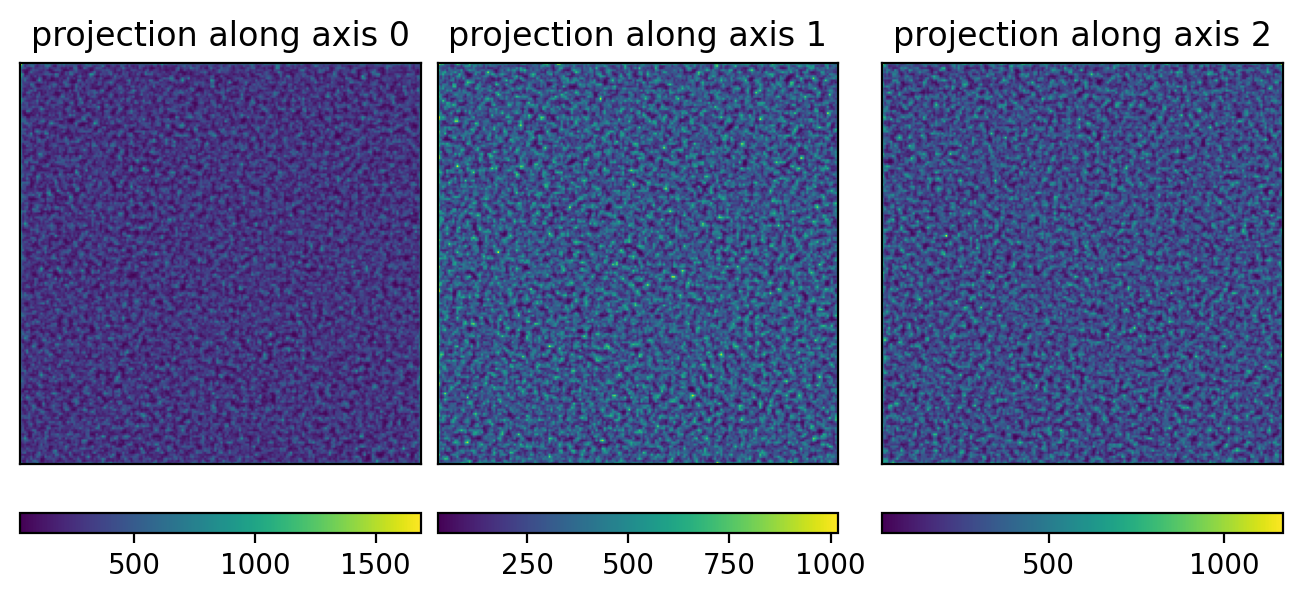

In [76]:
trim_px = 2
trimmed_vol = ice_vol_3d[trim_px:-trim_px, trim_px:-trim_px, trim_px:-trim_px]
plot3d(trimmed_vol)

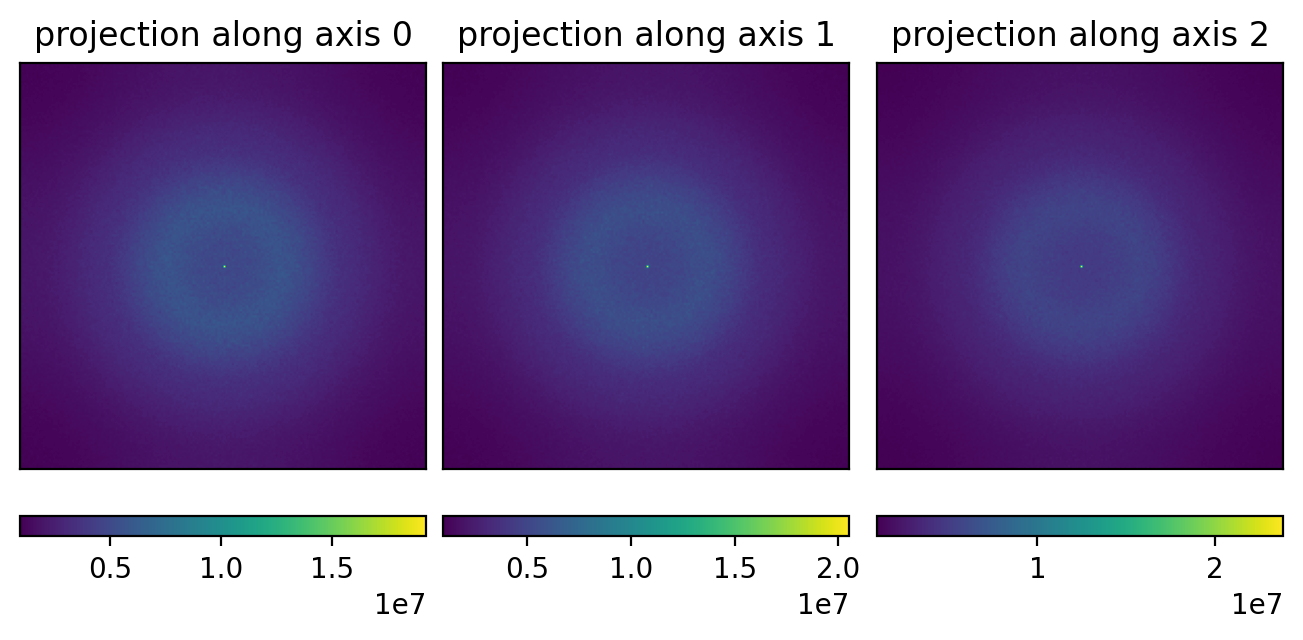

In [82]:
trimmed_vol_f = fftn(trimmed_vol)
plot3d((torch.abs(trimmed_vol_f)))

In [119]:
m = nn.Upsample(scale_factor=2, mode='trilinear')

In [120]:
trimmed_vol_f_imag = torch.imag(trimmed_vol_f)
trimmed_vol_f_real = torch.real(trimmed_vol_f)

In [121]:
test_imag = m(trimmed_vol_f_imag[None, None, ...])
test_real = m(trimmed_vol_f_real[None, None, ...])
test = torch.complex(test_real, test_imag)

In [122]:
test.shape

torch.Size([1, 1, 392, 392, 392])

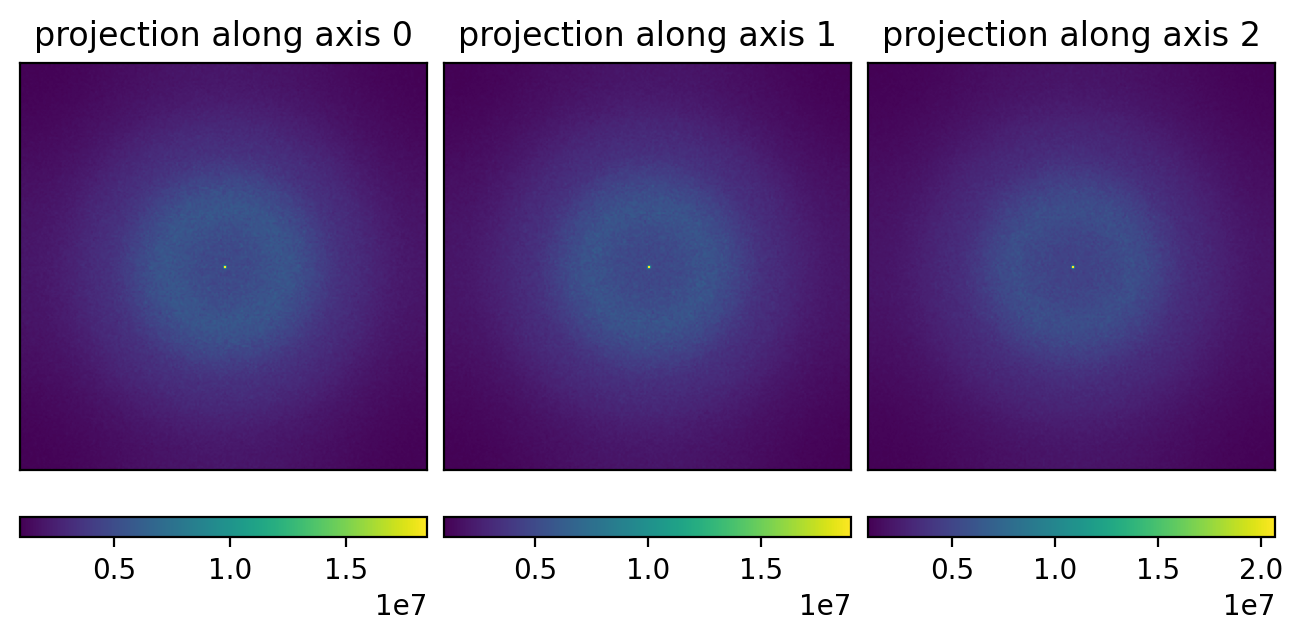

In [123]:
plot3d((torch.abs(test.squeeze())))

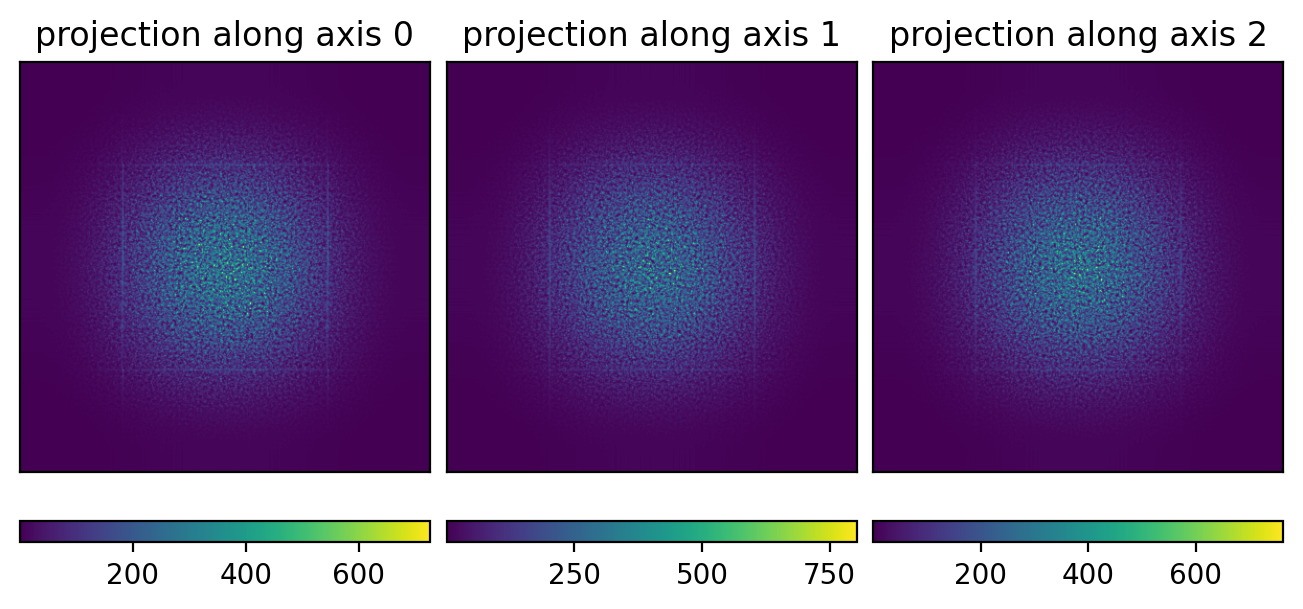

In [124]:
plot3d((torch.abs(ifftn(test.squeeze()))))